In [63]:
from langgraph.graph import StateGraph,START,END

from typing import Any, Dict, List, Optional, Tuple,TypedDict
from pydantic import BaseModel, Field

In [64]:
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
# Load environment variables (API Key)
load_dotenv()
model=ChatOpenAI(api_key=os.getenv('KEY'),
                 base_url="https://api.deepseek.com/v1",
    model="deepseek-chat")

In [65]:
class EvaluationSchema(BaseModel):
    feedback: str = Field( description = "concise feedback of the essay")
    score: int = Field(description= "score out of 10")

In [66]:
def parse_structured_output(response_text):
    """Parse the model response into EvaluationSchema"""
    import json
    return EvaluationSchema(**json.loads(response_text))

In [67]:
prompt = f'Evaluate the following essay on the role of AI in the software industry and its impact on human work. Provide concise feedback and a score out of 10 based on the quality of arguments, clarity, and depth of analysis.\n\nEssay:\n{essay}\n\nFeedback and Score out of 10'

In [68]:
response = model.invoke([
    {"role": "system", "content": "You are an essay evaluator. Respond in JSON format with keys: feedback (string) and score (integer out of 10)."},
    {"role": "user", "content": prompt}
])
parsed = parse_structured_output(response.content)
parsed

EvaluationSchema(feedback='The essay presents a well-structured and balanced argument on the role of AI in the software industry. It effectively covers key areas like code generation, testing, project management, and cybersecurity, while also addressing the limitations of AI in creativity, ethics, and contextual understanding. The use of case studies and discussion of societal implications adds depth. However, the analysis could be strengthened by offering more specific examples or data to support claims, and some sections (e.g., the efficiency argument) could be more concise. Overall, the clarity and logical flow are strong, but the depth of analysis is slightly moderate rather than deeply critical.', score=8)

In [69]:
import operator
from typing import Annotated

class UPSCState(TypedDict):
    essay:str
    language_feedback : str
    analysis_feedback: str
    clarity_feedback :str
    
    overall_feedback: str
    individual_score : Annotated[list[int], operator.add]
    avg_score: float

In [70]:
def evaluate_language(state:UPSCState)->str:
    prompt = f'Evaluate the following essay : {state["essay"]} on the AI industry and its consequences in concise manner,Provide me feedback to assign a number out of 10. '
    response = model.invoke([
        {"role": "system", "content": "You are an essay evaluator. Respond in JSON format with keys: feedback (string) and score (integer out of 10)."},
        {"role": "user", "content": prompt}
    ])
    output = parse_structured_output(response.content)
    return {'language_feedback': output.feedback, 'individual_score':[output.score]}

In [71]:
def evaluate_analysis(state:UPSCState)->str:
    prompt = f'Make an analysis of the following essay : {state["essay"]} on the AI industry and its consequences in concise manner,Provide me feedback to assign a number out of 10. '
    response = model.invoke([
        {"role": "system", "content": "You are an essay evaluator. Respond in JSON format with keys: feedback (string) and score (integer out of 10)."},
        {"role": "user", "content": prompt}
    ])
    output = parse_structured_output(response.content)
    return {'analysis_feedback': output.feedback, 'individual_score':[output.score]}

In [72]:
def evaluate_clarity(state:UPSCState)->str:
    prompt = f'Evaluate the clarity of the following essay : {state["essay"]} on the AI industry and its consequences in concise manner,Provide me feedback to assign a number out of 10. '
    response = model.invoke([
        {"role": "system", "content": "You are an essay evaluator. Respond in JSON format with keys: feedback (string) and score (integer out of 10)."},
        {"role": "user", "content": prompt}
    ])
    output = parse_structured_output(response.content)
    return {'clarity_feedback': output.feedback, 'individual_score':[output.score]}

In [73]:
def final_evaluation(state:UPSCState):
    prompt = f'Based on the following feedback, give me a summarized feedback here are the feedbacks,The analysis feedback is this : {state["analysis_feedback"]};The clarity feedback is this: {state["clarity_feedback"]};The language feedback is this: {state["language_feedback"]}'
    overall_feedback = model.invoke(prompt).content
    avg_score = sum(state['individual_score']) / len(state['individual_score'])

    return {'overall_feedback':overall_feedback,'avg_score':avg_score}

In [74]:
import operator
from typing import Annotated

graph = StateGraph(UPSCState)

graph.add_node("evaluate_language",evaluate_language)
graph.add_node("evaluate_analysis",evaluate_analysis)
graph.add_node("evaluate_clarity",evaluate_clarity)   
graph.add_node("evaluate_final",final_evaluation) 


##edges 
graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_analysis')
graph.add_edge(START,'evaluate_clarity')

graph.add_edge('evaluate_language','evaluate_final')
graph.add_edge('evaluate_analysis','evaluate_final')
graph.add_edge('evaluate_clarity','evaluate_final')


graph.add_edge('evaluate_final',END)

workflow = graph.compile()




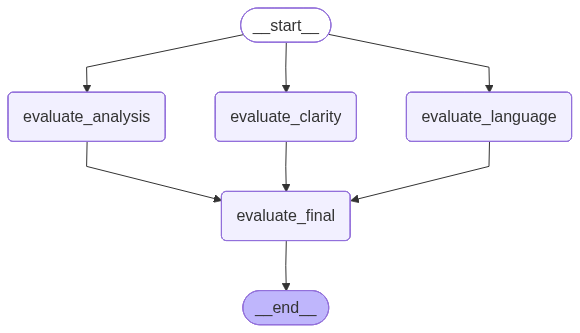

In [75]:
workflow

In [81]:
initial_state ={
    'essay': essay,
    
}

workflow.invoke(initial_state)

{'essay': 'AI in Software: Mist and Machinery\nArtificial Intelligence in the software industry is less a tool than a drifting presence, half‑seen, half‑understood. It writes code, or echoes code, or produces something that resembles code but not quite. Developers look at lines appearing, sometimes useful, sometimes puzzling, sometimes both, and the origin feels blurred—was it the machine, was it the human, or was it some mixture neither can claim?\n\nTesting becomes a foggy ritual. Predictions arrive, probabilities hum, bugs are caught or missed, and the certainty dissolves. Project timelines emerge from algorithms, but they are not firm, not fragile, just hovering suggestions that shape decisions without anchoring them. Security systems scan endlessly, eyes everywhere, yet the meaning of what they see remains unsettled, requiring human judgment to decide if the shadow is threat or illusion.\n\nThe talk of replacement grows louder: machines never tire, never pause, never forget. But h

In [80]:
essay="""AI in Software: Mist and Machinery
Artificial Intelligence in the software industry is less a tool than a drifting presence, half‑seen, half‑understood. It writes code, or echoes code, or produces something that resembles code but not quite. Developers look at lines appearing, sometimes useful, sometimes puzzling, sometimes both, and the origin feels blurred—was it the machine, was it the human, or was it some mixture neither can claim?

Testing becomes a foggy ritual. Predictions arrive, probabilities hum, bugs are caught or missed, and the certainty dissolves. Project timelines emerge from algorithms, but they are not firm, not fragile, just hovering suggestions that shape decisions without anchoring them. Security systems scan endlessly, eyes everywhere, yet the meaning of what they see remains unsettled, requiring human judgment to decide if the shadow is threat or illusion.

The talk of replacement grows louder: machines never tire, never pause, never forget. But humans linger in the spaces machines cannot fill—creativity, ethics, context, imagination. AI can generate, but can it invent? It can detect, but can it decide?

The future is neither clear replacement nor clear resistance. It is haze, overlap, confusion: humans and machines together, sometimes partners, sometimes rivals, sometimes shadows of each other, shaping software in ways no one fully understands."""